In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.formula.api import ols

In [2]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

__Mean exposure to light__

In [3]:
df = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'Mean_light_daily')

In [4]:
#in column timerange_0night, 0 is day, 1 is night 
#rename as day and night
#df['timerange_0night'] = df['timerange_0night'].replace({0: 'night', 1: 'day'})
df['location_0_ita'] = df['location_0_ita'].replace({0: 'ita', 1: 'uk'})

In [5]:
df_daylight1 = pd.read_excel(fpath + '\\1.0_sunset_sunrise_UTC.xlsx', sheet_name='Sheet1')

In [6]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 1:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 0:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

df_daylight1[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df_daylight1.apply(adjust_value, axis=1, result_type='expand')

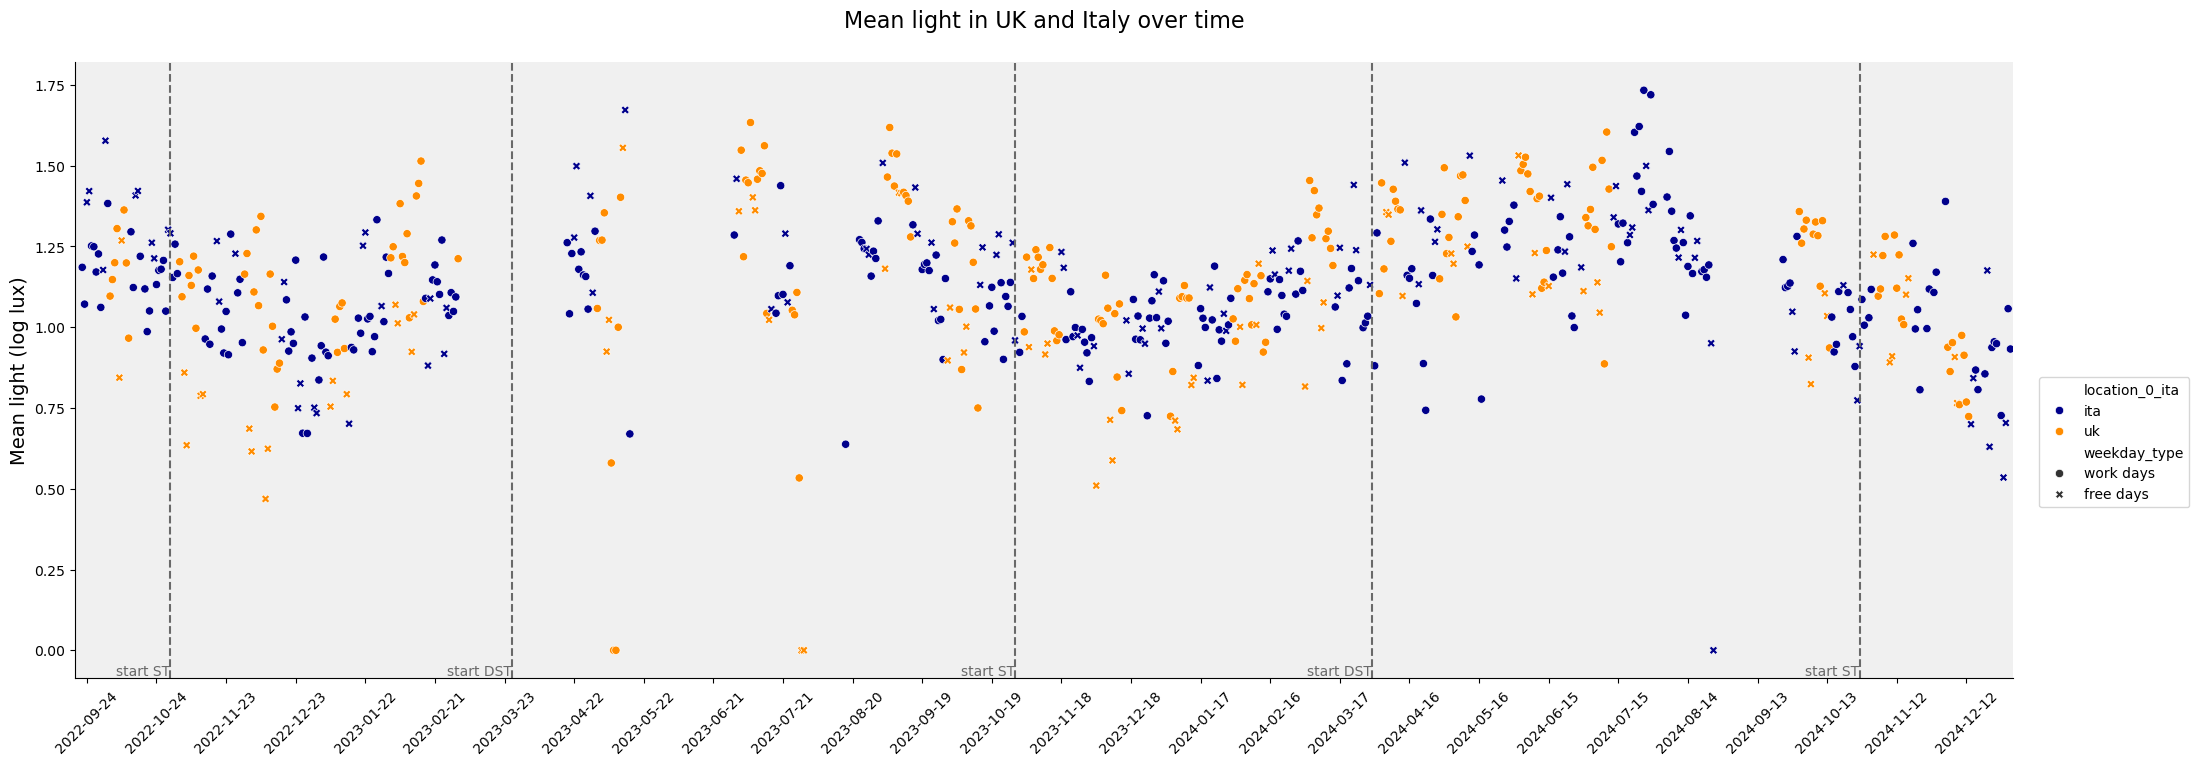

In [7]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='mean_light', hue='location_0_ita', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)


# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Mean light (log lux)', fontsize=14)
ax1.set_title('Mean light in UK and Italy over time\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 0.5)) 

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

In [8]:
# Plot the mean light data over time, marking night and day, grouped by season and weekday_type
#plt.figure(figsize=(15, 10))
#sns.scatterplot(x='date_start', y='mean_light', hue='timerange_0night', size='weekday_type', data=df, sizes=(10, 50))
#plt.xlabel('Date')
#plt.ylabel('Mean Light')
#plt.title('Mean Light over Time (Day vs Night) with Weekday Type')
#plt.legend(title='Time Range')
#plt.legend(title='Time Range', bbox_to_anchor=(1.05, 1.02), loc='upper left')

#plt.show()

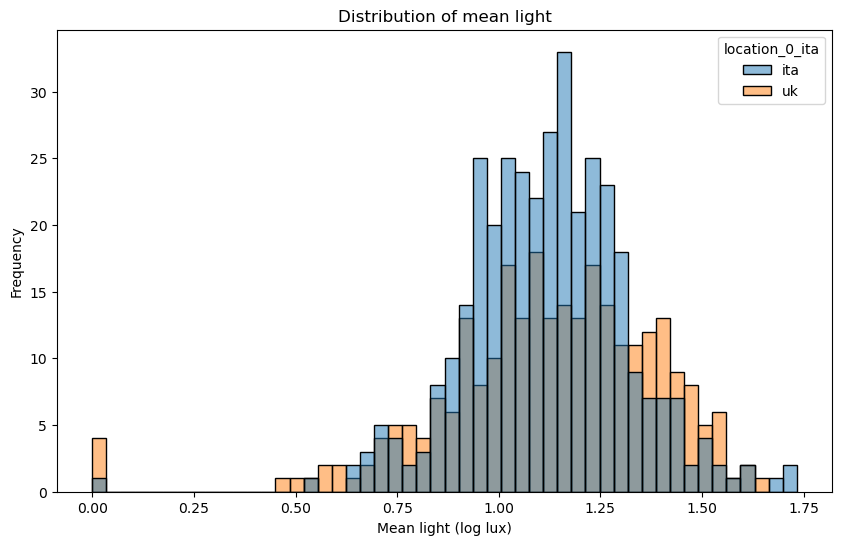

In [9]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='mean_light', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('Mean light (log lux)')
plt.ylabel('Frequency')
plt.title('Distribution of mean light')
plt.show()

In [10]:
# remove light les than 0.1
df = df[df['mean_light'] > 0.1]

In [11]:
shapiro_test = stats.shapiro(df['mean_light'])
#shapiro_test_day = stats.shapiro(df_day['mean_light'])   
#shapiro_test_night = stats.shapiro(df_night['mean_light'])

In [12]:
shapiro_test #, shapiro_test_day, shapiro_test_night

ShapiroResult(statistic=0.9975569642729777, pvalue=0.48926495427234223)

In [13]:
t_test_result = stats.ttest_ind(df[df['location_0_ita'] == 'ita']['mean_light'], df[df['location_0_ita'] == 'uk']['mean_light'])

t_test_result

TtestResult(statistic=-1.2103099203928929, pvalue=0.2266160556684837, df=627.0)

In [14]:
# Descriptive statistics for 'mean_light' by location
df_mean_light = df.groupby('location_0_ita')['mean_light'].describe()

df_mean_light

,count,mean,std,min,25%,50%,75%,max
location_0_ita,,,,,,,,
ita,359.0,1.119572,0.19076,0.534663,0.995061,1.122708,1.242520,1.733132
uk,270.0,1.140131,0.23496,0.468470,0.997791,1.148460,1.322532,1.633352


In [15]:
# Regression analysis for day
model = smf.ols(
    'mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)',
    data=df
).fit()

# Display the regression summaries
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     99.21
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           1.57e-52
Time:                        10:45:33   Log-Likelihood:                 209.32
No. Observations:                 629   AIC:                            -410.6
Df Residuals:                     625   BIC:                            -392.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        0.5736      0.033     17.142      0.000       0.508       0.639
C(location_0_ita)[T.uk]          0.0214      0.014      1.523      0.128      -0.006       0.049
C(weekday_type)[T.work days]     0.0489      0.015      3.187      0.002       0.019       0.079
photoperiod                      0.0446      0.003     16.912      0.000       0.039       0.050
==============================================================================
Omnibus:                       41.897   Durbin-Watson:                   1.344
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.976
Skew:                          -0.482   Prob(JB):                     1.73e-15
Kurtosis:                       4.290   Cond. No.                         58.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
# perform a multifactors ANOVA to test the effect of location, season and weekday_type on TATp10_min
model_df = ols('mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)', data=df).fit()
anova_df = sm.stats.anova_lm(model_df, typ=3)
anova_df

,sum_sq,df,F,PR(>F)
Intercept,8.899970,1.0,293.864108,2.795090e-54
C(location_0_ita),0.070291,1.0,2.320918,1.281505e-01
C(weekday_type),0.307593,1.0,10.156291,1.509807e-03
photoperiod,8.662707,1.0,286.030014,4.096638e-53
Residual,18.928754,625.0,NaN,NaN


In [17]:
# mean and std of mean light by location and weekday_type

In [18]:
# coefficient of the anoav model
model_df.params 


Intercept                       0.573625
C(location_0_ita)[T.uk]         0.021365
C(weekday_type)[T.work days]    0.048865
photoperiod                     0.044587
dtype: float64

Seasons

In [19]:
df_summer = df[df['season'] == 'Summer']

df_winter = df[df['season'] == 'Winter']

-In Summer

In [20]:
utest_loc_s = stats.mannwhitneyu(df_summer[df_summer['location_0_ita'] == 'ita']['mean_light'], df_summer[df_summer['location_0_ita'] == 'uk']['mean_light'])

utest_loc_s

MannwhitneyuResult(statistic=1147.0, pvalue=0.020609234036098004)

In [21]:
summer_loc = df_summer.groupby('location_0_ita')['mean_light'].describe()
summer_loc

,count,mean,std,min,25%,50%,75%,max
location_0_ita,,,,,,,,
ita,72.0,1.269619,0.173671,0.637686,1.183395,1.261583,1.348135,1.733132
uk,43.0,1.327718,0.223545,0.533380,1.199455,1.401774,1.470146,1.633352


-In Winter

In [22]:
utest_loc_w = stats.mannwhitneyu(df_winter[df_winter['location_0_ita'] == 'ita']['mean_light'], df_winter[df_winter['location_0_ita'] == 'uk']['mean_light'])

utest_loc_w

MannwhitneyuResult(statistic=2614.0, pvalue=0.023179140706657685)

In [23]:
winter_loc = df_winter.groupby('location_0_ita')['mean_light'].describe()
winter_loc

,count,mean,std,min,25%,50%,75%,max
location_0_ita,,,,,,,,
ita,105.0,1.013006,0.157208,0.534663,0.937068,1.027972,1.110149,1.332498
uk,63.0,1.086212,0.197435,0.683880,0.954840,1.088397,1.213251,1.514039


_Mean light exposure 7:00-17:00_

In [24]:
df_range = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = '7_17_meanlight')

In [25]:
#in column timerange_0night, 0 is day, 1 is night 
#rename as day and night
#df['timerange_0night'] = df['timerange_0night'].replace({0: 'night', 1: 'day'})
df_range['location_0_ita'] = df_range['location_0_ita'].replace({0: 'ita', 1: 'uk'})

In [26]:
df_daylight1 = pd.read_excel(fpath + '\\1.0_sunset_sunrise_UTC.xlsx', sheet_name='Sheet1')

In [27]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 1:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 0:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

df_daylight1[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df_daylight1.apply(adjust_value, axis=1, result_type='expand')

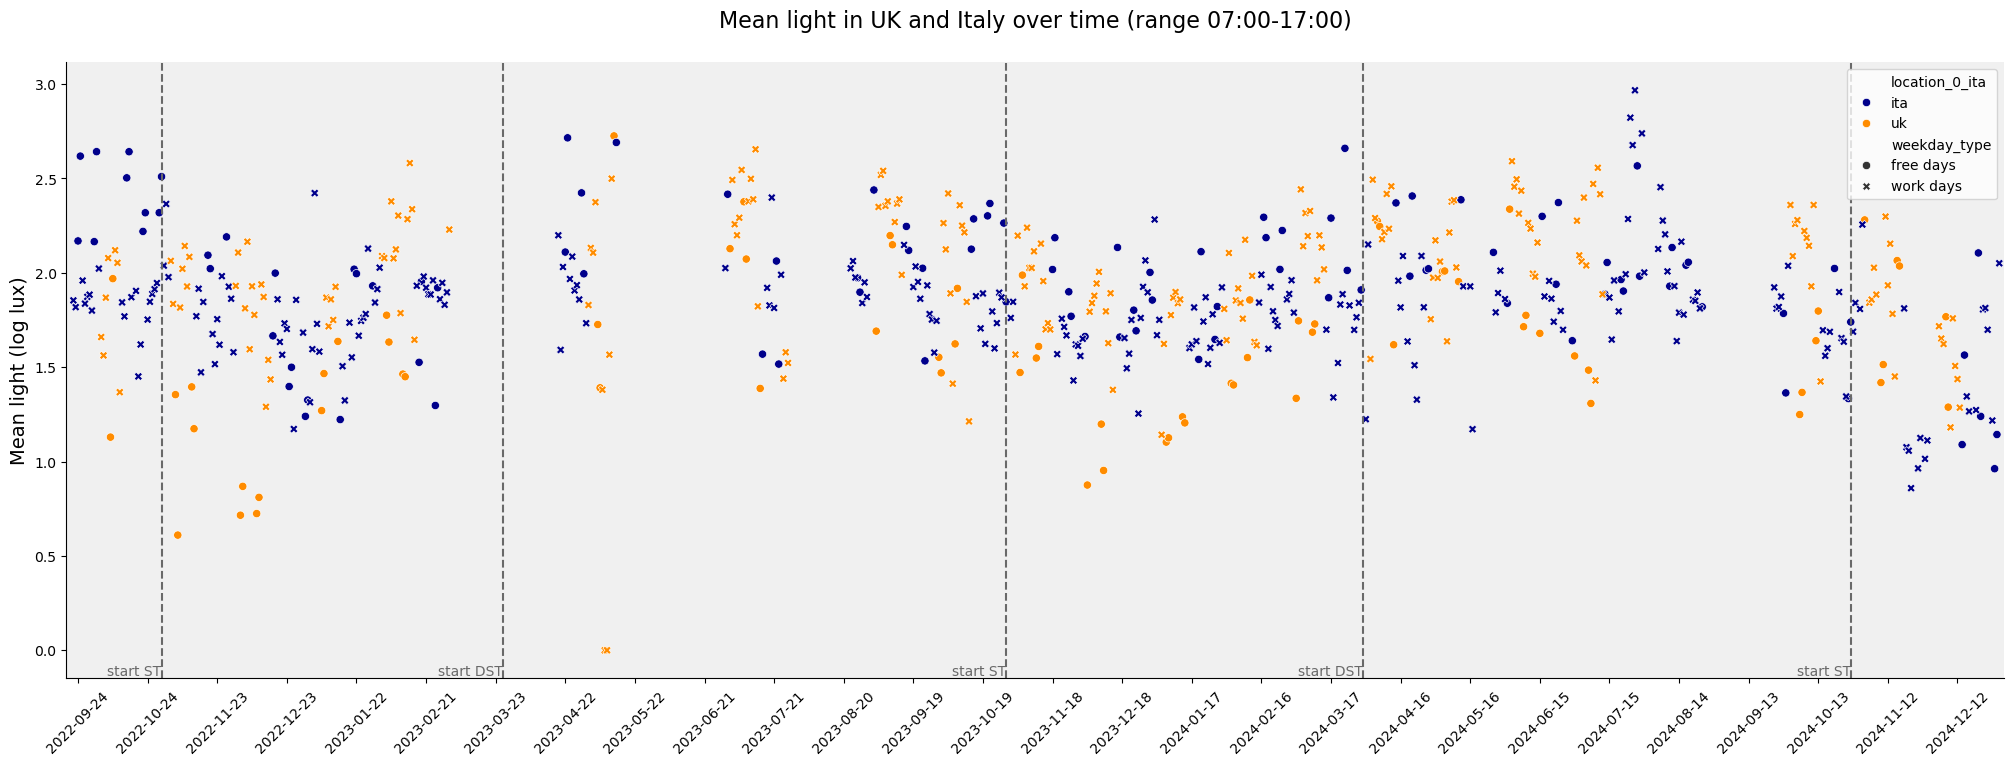

In [28]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='mean_light', hue='location_0_ita', style='weekday_type', data=df_range, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)


# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Mean light (log lux)', fontsize=14)
ax1.set_title('Mean light in UK and Italy over time (range 07:00-17:00)\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

In [29]:
# Plot the mean light data over time, marking night and day, grouped by season and weekday_type
#plt.figure(figsize=(15, 10))
#sns.scatterplot(x='date_start', y='mean_light', hue='timerange_0night', size='weekday_type', data=df, sizes=(10, 50))
#plt.xlabel('Date')
#plt.ylabel('Mean Light')
#plt.title('Mean Light over Time (Day vs Night) with Weekday Type')
#plt.legend(title='Time Range')
#plt.legend(title='Time Range', bbox_to_anchor=(1.05, 1.02), loc='upper left')

#plt.show()

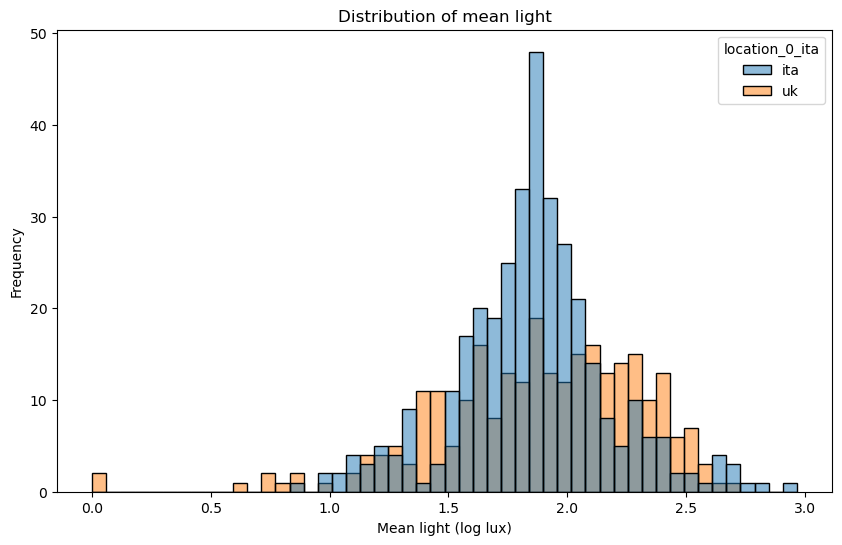

In [30]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_range, x='mean_light', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('Mean light (log lux)')
plt.ylabel('Frequency')
plt.title('Distribution of mean light')
plt.show()

In [31]:
# remove light les than 0.1
df_range = df_range[df_range['mean_light'] > 0.1]

In [32]:
shapiro_test = stats.shapiro(df_range['mean_light'].dropna())
#shapiro_test_day = stats.shapiro(df_day['mean_light'])   
#shapiro_test_night = stats.shapiro(df_night['mean_light'])

In [33]:
shapiro_test #, shapiro_test_day, shapiro_test_night

ShapiroResult(statistic=0.9922336149701679, pvalue=0.002538673583321687)

In [34]:
utest_location = stats.mannwhitneyu(df_range[df_range['location_0_ita'] == 'ita']['mean_light'].dropna(), df_range[df_range['location_0_ita'] == 'uk']['mean_light'].dropna())

utest_location

MannwhitneyuResult(statistic=42593.0, pvalue=0.03677596771530628)

In [35]:
# Descriptive statistics for 'mean_light' by location
df_mean_light = df_range.groupby('location_0_ita')['mean_light'].describe()

df_mean_light

,count,mean,std,min,25%,50%,75%,max
location_0_ita,,,,,,,,
ita,351.0,1.852271,0.325160,0.858826,1.679089,1.858851,2.011663,2.966562
uk,269.0,1.890225,0.403302,0.610202,1.623110,1.928056,2.198408,2.724911


In [36]:
# Regression analysis for day
model = smf.ols(
    'mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)',
    data=df_range
).fit()

# Display the regression summaries
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             mean_light   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     47.13
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           1.99e-27
Time:                        10:45:35   Log-Likelihood:                -184.05
No. Observations:                 620   AIC:                             376.1
Df Residuals:                     616   BIC:                             393.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        1.1389      0.063     17.977      0.000       1.014       1.263
C(location_0_ita)[T.uk]          0.0379      0.026      1.432      0.153      -0.014       0.090
C(weekday_type)[T.work days]     0.0756      0.029      2.620      0.009       0.019       0.132
photoperiod                      0.0577      0.005     11.538      0.000       0.048       0.068
==============================================================================
Omnibus:                        6.583   Durbin-Watson:                   1.184
Prob(Omnibus):                  0.037   Jarque-Bera (JB):                6.496
Skew:                          -0.219   Prob(JB):                       0.0388
Kurtosis:                       3.244   Cond. No.                         58.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [37]:
# perform a multifactors ANOVA to test the effect of location, season and weekday_type on TATp10_min
model_df_range = ols('mean_light ~ C(location_0_ita) + photoperiod + C(weekday_type)', data=df_range).fit()
anova_df_range = sm.stats.anova_lm(model_df_range, typ=3)
anova_df_range

,sum_sq,df,F,PR(>F)
Intercept,34.483741,1.0,323.170902,2.102878e-58
C(location_0_ita),0.218915,1.0,2.051599,1.525537e-01
C(weekday_type),0.732243,1.0,6.862355,9.019911e-03
photoperiod,14.204930,1.0,133.124191,5.095782e-28
Residual,65.729880,616.0,NaN,NaN


In [38]:
# coefficient of the anoav model
model_df_range.params 


Intercept                       1.138853
C(location_0_ita)[T.uk]         0.037935
C(weekday_type)[T.work days]    0.075632
photoperiod                     0.057695
dtype: float64

__Time above threshold (10-100-500-1000-2500)__

_TATp10_

In [39]:
df_TATp10 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_10')

In [40]:
# remove outliers according to 3 standard deviations
df_TATp10 = df_TATp10[np.abs(df_TATp10['TATp10_min'] - df_TATp10['TATp10_min'].mean()) <= (3 * df_TATp10['TATp10_min'].std())]

In [41]:
df_TATp10['location_0_ita'] = df_TATp10['location_0_ita'].replace({0: 'ita', 1: 'uk'})

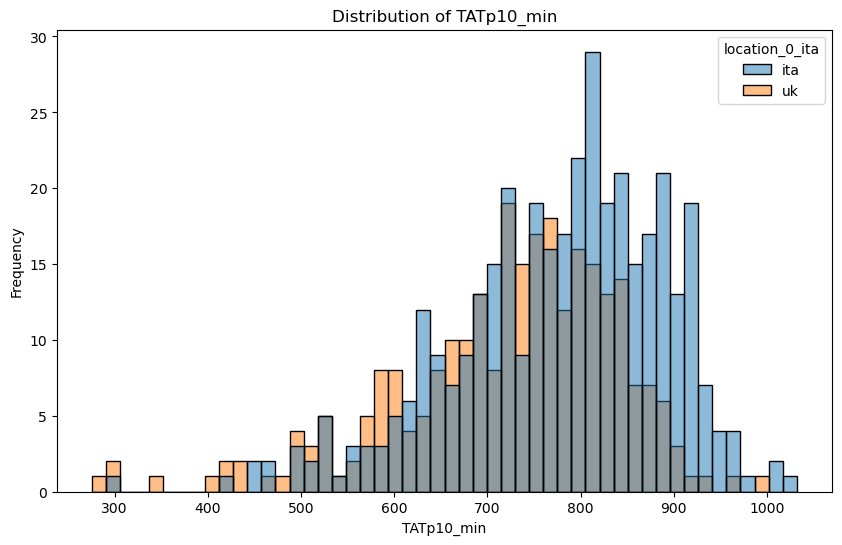

In [42]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp10, x='TATp10_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp10_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp10_min')
plt.show()

In [43]:
shapiro_test_tatp10 = stats.shapiro(df_TATp10['TATp10_min'])

shapiro_test_tatp10

ShapiroResult(statistic=0.9653724938155483, pvalue=3.0069543635476924e-11)

In [44]:
utest_location_tatp10 = stats.mannwhitneyu(df_TATp10[df_TATp10['location_0_ita'] == 'ita']['TATp10_min'], df_TATp10[df_TATp10['location_0_ita'] == 'uk']['TATp10_min'])

utest_location_tatp10

MannwhitneyuResult(statistic=64868.0, pvalue=6.866689427935188e-09)

In [45]:
# grpup by location and mean,std,min and max of 'TATp10_min
df_TATp10_loc = df_TATp10.groupby('location_0_ita').agg({'TATp10_min': ['mean', 'std', 'min', 'max']})
df_TATp10_loc

TATp10_min                           
                      mean         std    min     max
location_0_ita                                       
ita             775.219577  115.042343  301.5  1032.0
uk              721.426199  119.856342  276.0   992.5

In [46]:
# perform a multifactors ANOVA to test the effect of location, season and weekday_type on TATp10_min
model_tatp10 = ols('TATp10_min ~ C(location_0_ita) + photoperiod + C(weekday_type)', data=df_TATp10).fit()
anova_table = sm.stats.anova_lm(model_tatp10, typ=3)
anova_table

,sum_sq,df,F,PR(>F)
Intercept,7.484989e+06,1.0,713.881112,1.854179e-106
C(location_0_ita),4.442021e+05,1.0,42.365796,1.521608e-10
C(weekday_type),7.783246e+05,1.0,74.232744,5.334453e-17
photoperiod,1.332434e+06,1.0,127.080930,4.979515e-27
Residual,6.762776e+06,645.0,NaN,NaN


In [47]:
# coefficient of the anoav model
model_tatp10.params 


Intercept                       521.260035
C(location_0_ita)[T.uk]         -53.058515
C(weekday_type)[T.work days]     76.967377
photoperiod                      17.284632
dtype: float64

In [ ]:
# Regression analysis for night
model_TATp10 = smf.ols(
    "TATp10_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp10
).fit()

model_TATp10.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             TATp10_min   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     33.32
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           1.21e-08
Time:                        10:46:34   Log-Likelihood:                -4011.0
No. Observations:                 649   AIC:                             8026.
Df Residuals:                     647   BIC:                             8035.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 775.2196      6.022    128.738      0.000     763.395     787.044
C(location_0_ita)[T.uk]   -53.7934      9.319     -5.773      0.000     -72.092     -35.495
==============================================================================
Omnibus:                       70.999   Durbin-Watson:                   1.094
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.397
Skew:                          -0.827   Prob(JB):                     1.93e-21
Kurtosis:                       3.891   Cond. No.                         2.47
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
#The coefficient estimate in the output indicate the average change in the log odds of the response variable associated with a one unit increase in each predictor variable.

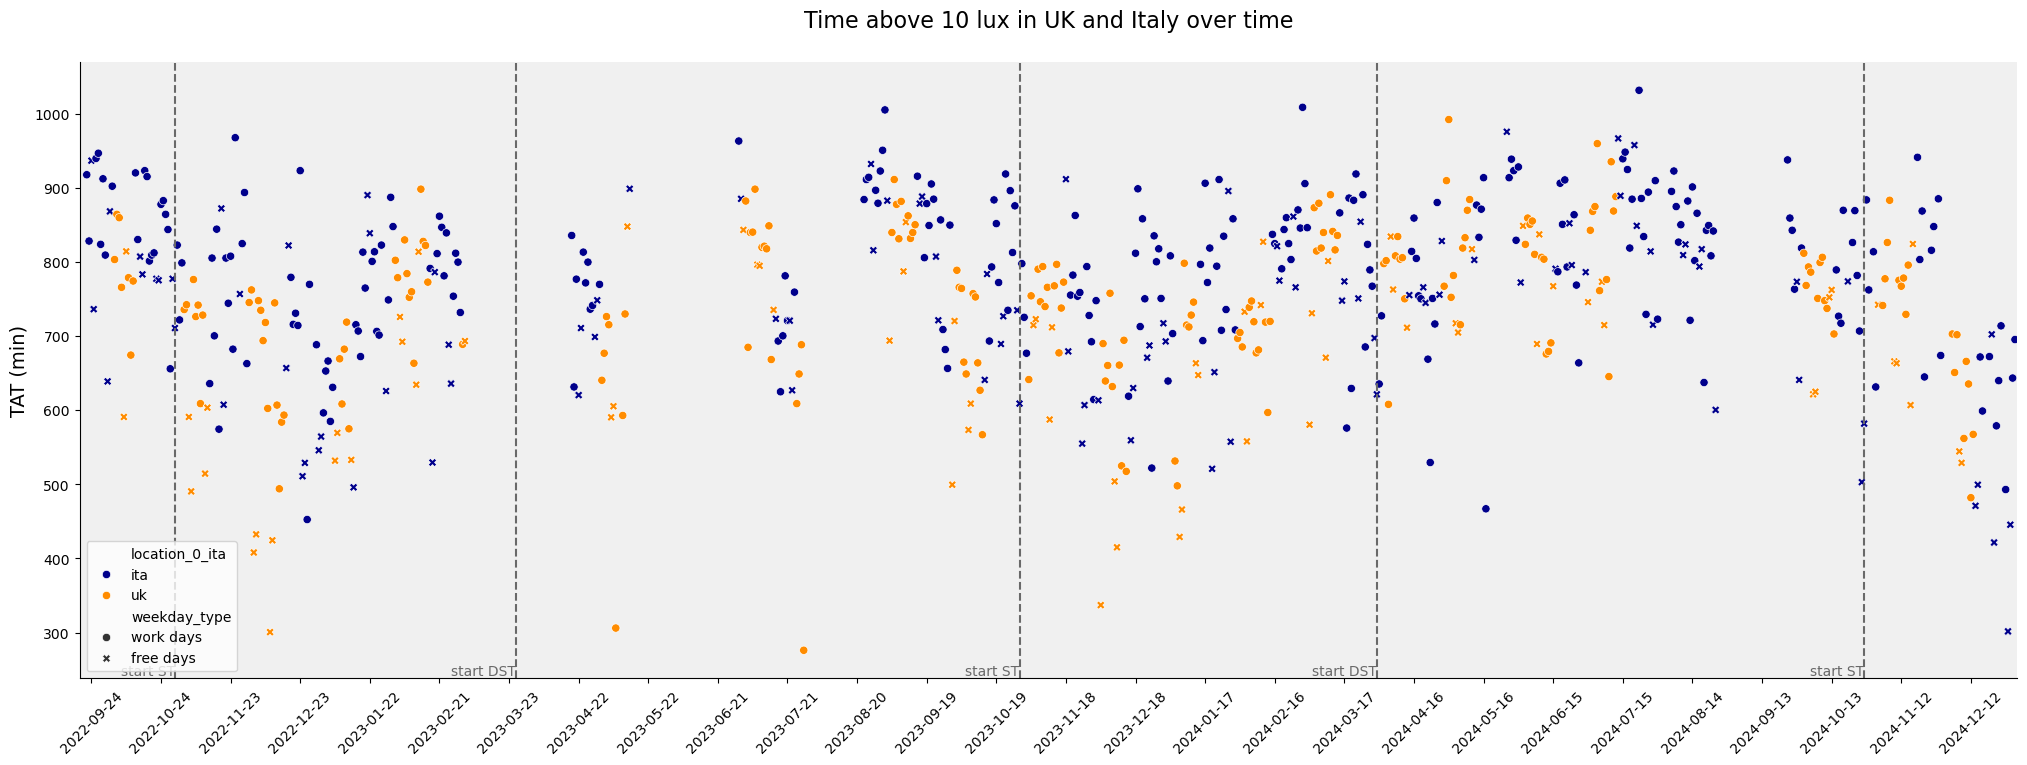

In [50]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='TATp10_min', hue='location_0_ita', style='weekday_type', data=df_TATp10, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('TAT (min)', fontsize=14)
ax1.set_title('Time above 10 lux in UK and Italy over time\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

_TATp100_

In [51]:
df_TATp100 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_100')

In [52]:
# remove outliers according to 3 standard deviations
#df_TATp100 = df_TATp100[np.abs(df_TATp100['TATp100_min'] - df_TATp100['TATp100_min'].mean()) <= (3 * df_TATp100['TATp100_min'].std())]

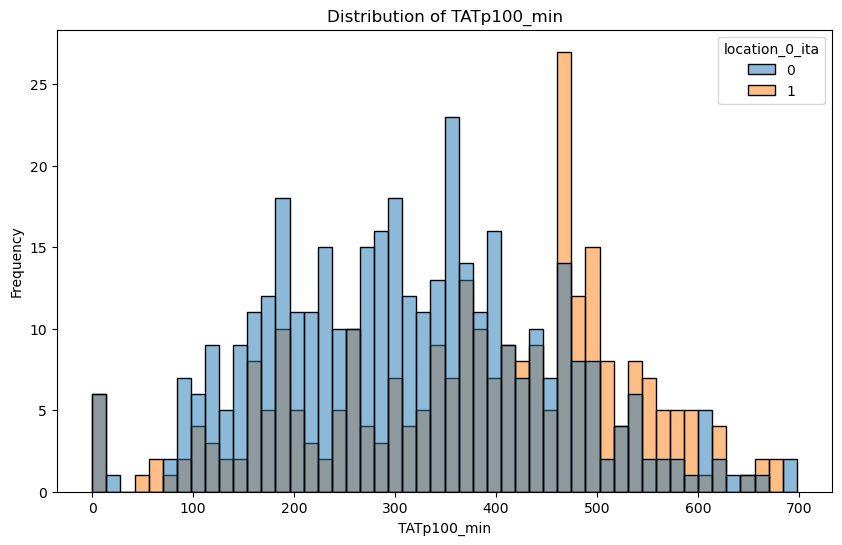

In [53]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp100, x='TATp100_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp100_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp100_min')
plt.show()

In [54]:
shapiro_test_tatp100 = stats.shapiro(df_TATp100['TATp100_min'])

shapiro_test_tatp100

ShapiroResult(statistic=0.9908388455240059, pvalue=0.0003895528353952918)

In [55]:
df_TATp100['location_0_ita'] = df_TATp100['location_0_ita'].replace({0: 'ita', 1: 'uk'})

In [56]:
utest_location_tatp100 = stats.mannwhitneyu(df_TATp100[df_TATp100['location_0_ita'] == 'ita']['TATp100_min'], df_TATp100[df_TATp100['location_0_ita'] == 'uk']['TATp100_min'])

utest_location_tatp100

MannwhitneyuResult(statistic=39033.5, pvalue=3.004991966933346e-09)

In [57]:
# by location and mean,std,min and max of 'TATp100_min
df_TATp100_loc = df_TATp100.groupby('location_0_ita').agg({'TATp100_min': ['mean', 'std', 'min', 'max']})
df_TATp100_loc

TATp100_min                        
                      mean         std  min    max
location_0_ita                                    
ita             313.915803  136.993606  0.0  698.0
uk              376.229242  151.620219  0.0  684.0

In [58]:
# Regression analysis for night
model_TATp100 = smf.ols(
    "TATp100_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp100
).fit()

model_TATp100.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            TATp100_min   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     65.43
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           4.86e-37
Time:                        10:45:37   Log-Likelihood:                -4160.0
No. Observations:                 663   AIC:                             8328.
Df Residuals:                     659   BIC:                             8346.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       43.3108     24.258      1.785      0.075      -4.322      90.943
C(location_0_ita)[T.uk]         63.3335     10.146      6.242      0.000      43.412      83.255
C(weekday_type)[T.work days]    -6.5221     11.138     -0.586      0.558     -28.391      15.347
photoperiod                     23.8675      1.898     12.574      0.000      20.140      27.595
==============================================================================
Omnibus:                       34.536   Durbin-Watson:                   1.406
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.111
Skew:                          -0.511   Prob(JB):                     1.18e-09
Kurtosis:                       3.666   Cond. No.                         58.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

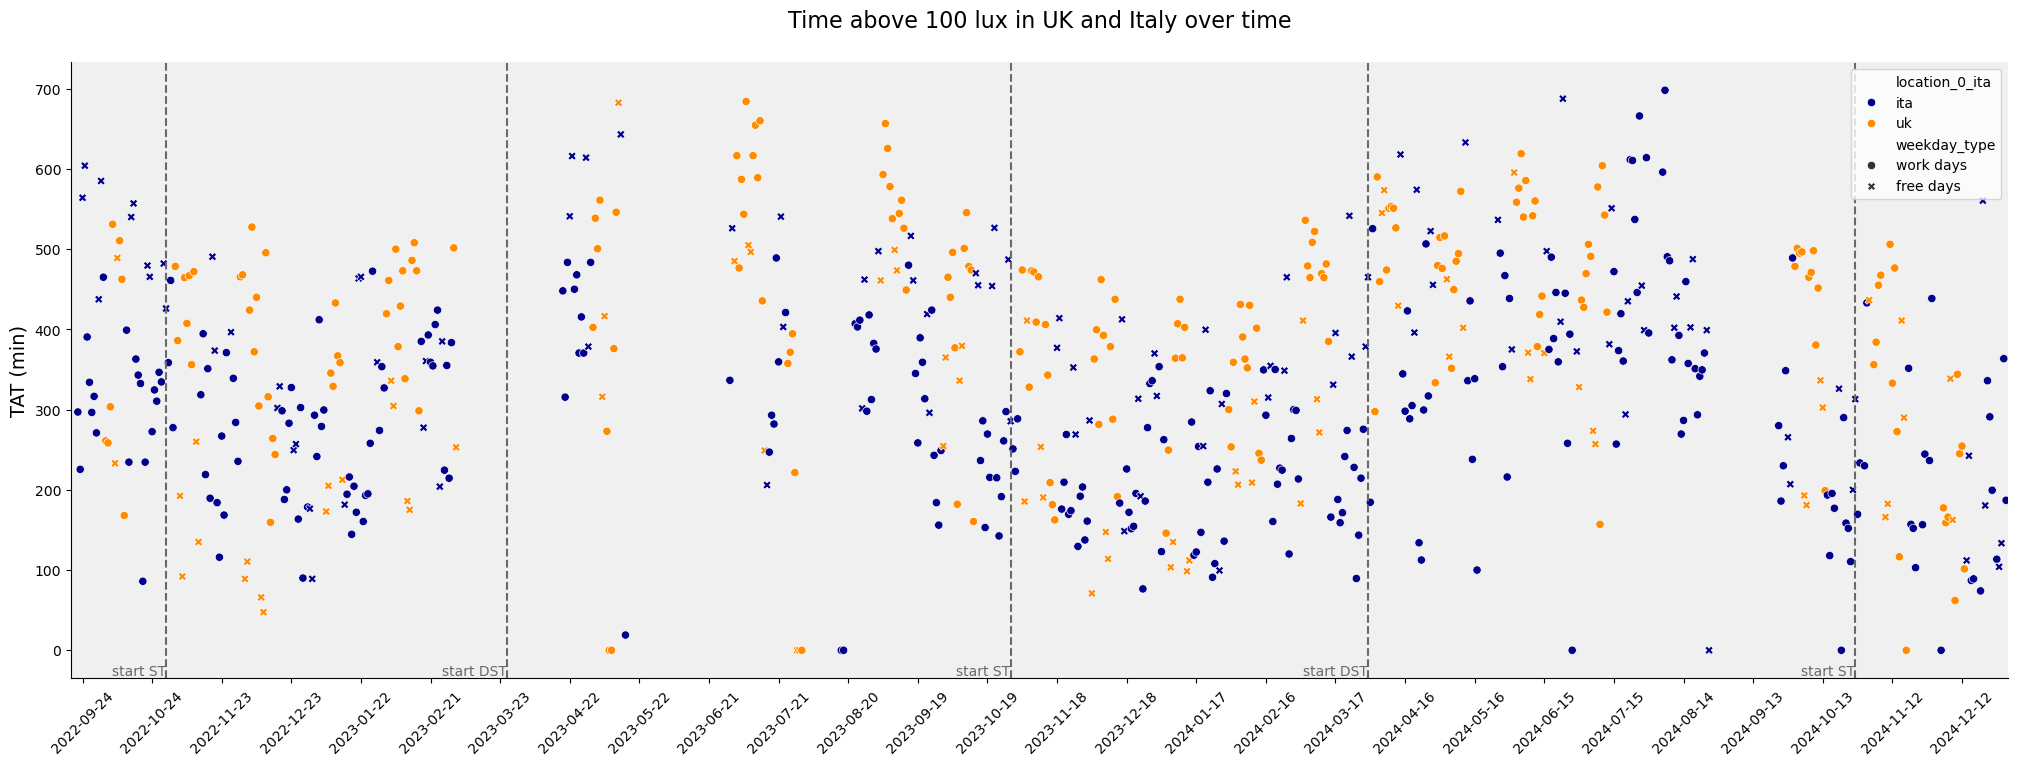

In [59]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='TATp100_min', hue='location_0_ita', style='weekday_type', data=df_TATp100, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('TAT (min)', fontsize=14)
ax1.set_title('Time above 100 lux in UK and Italy over time\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

_TATp500_

In [60]:
df_TATp500 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_500')

In [61]:
# remove value less than 0
df_TATp500 = df_TATp500[df_TATp500['TATp500_min'] > 1]

In [62]:
# remove outliers according to 3 standard deviations
#df_TATp490 = df_TATp490[np.abs(df_TATp490['TATp490_min'] - df_TATp490['TATp490_min'].mean()) <= (3 * df_TATp490['TATp490_min'].std())]

In [63]:
df_TATp500['location_0_ita'] = df_TATp500['location_0_ita'].replace({0: 'ita', 1: 'uk'})

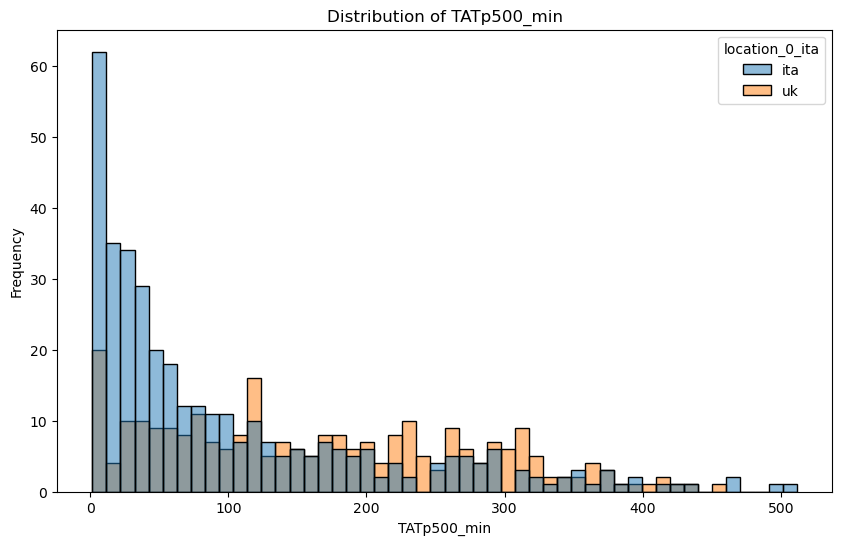

In [64]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp500, x='TATp500_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp500_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp500_min')
plt.show()

In [65]:
utest_location_tatp500 = stats.mannwhitneyu(df_TATp500[df_TATp500['location_0_ita'] == 'ita']['TATp500_min'], df_TATp500[df_TATp500['location_0_ita'] == 'uk']['TATp500_min'])

utest_location_tatp500

MannwhitneyuResult(statistic=30397.0, pvalue=6.242162122627723e-16)

In [66]:
# by location and mean,std,min and max of 'TATp500_min
df_TATp500_loc = df_TATp500.groupby('location_0_ita').agg({'TATp500_min': ['mean', 'median', 'std', 'min', 'max']})
df_TATp500_loc

TATp500_min                               
                      mean median         std  min    max
location_0_ita                                           
ita              99.284932   55.0  108.654867  1.5  511.5
uk              164.930712  150.5  112.360791  1.5  452.0

In [67]:
# Fix: Replace zero values in TATp500_min with a small positive value
df_TATp500["TATp500_min"] = df_TATp500["TATp500_min"].replace(0, 1e-6)

# Fit a GLM with Gamma distribution and correct log link function
glm_model_fixed = smf.glm(
    "TATp500_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp500,
    family=sm.families.Gamma(link=sm.families.links.Log())  # Fix deprecated log alias
).fit()

# Display the corrected regression summary
glm_model_fixed.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            TATp500_min   No. Observations:                  632
Model:                            GLM   Df Residuals:                      628
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                         0.85363
Method:                          IRLS   Log-Likelihood:                -3608.3
Date:                Thu, 24 Apr 2025   Deviance:                       622.29
Time:                        10:45:38   Pearson chi2:                     536.
No. Iterations:                    21   Pseudo R-squ. (CS):             0.2606
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        3.0926      0.179     17.294      0.000       2.742       3.443
C(location_0_ita)[T.uk]          0.6812      0.074      9.150      0.000       0.535       0.827
C(weekday_type)[T.work days]    -0.5404      0.082     -6.622      0.000      -0.700      -0.380
photoperiod                      0.1493      0.014     10.670      0.000       0.122       0.177
================================================================================================
"""

In [68]:
#convert the coefficients to the original scale and print them
coef = np.exp(glm_model_fixed.params)
print(coef)

Intercept                       22.033350
C(location_0_ita)[T.uk]          1.976219
C(weekday_type)[T.work days]     0.582542
photoperiod                      1.161002
dtype: float64


In [69]:
# convert the coef in percentage
coef = np.exp(glm_model_fixed.params) - 1
coef = coef * 100
print(coef)

Intercept                       2103.335037
C(location_0_ita)[T.uk]           97.621854
C(weekday_type)[T.work days]     -41.745788
photoperiod                       16.100185
dtype: float64


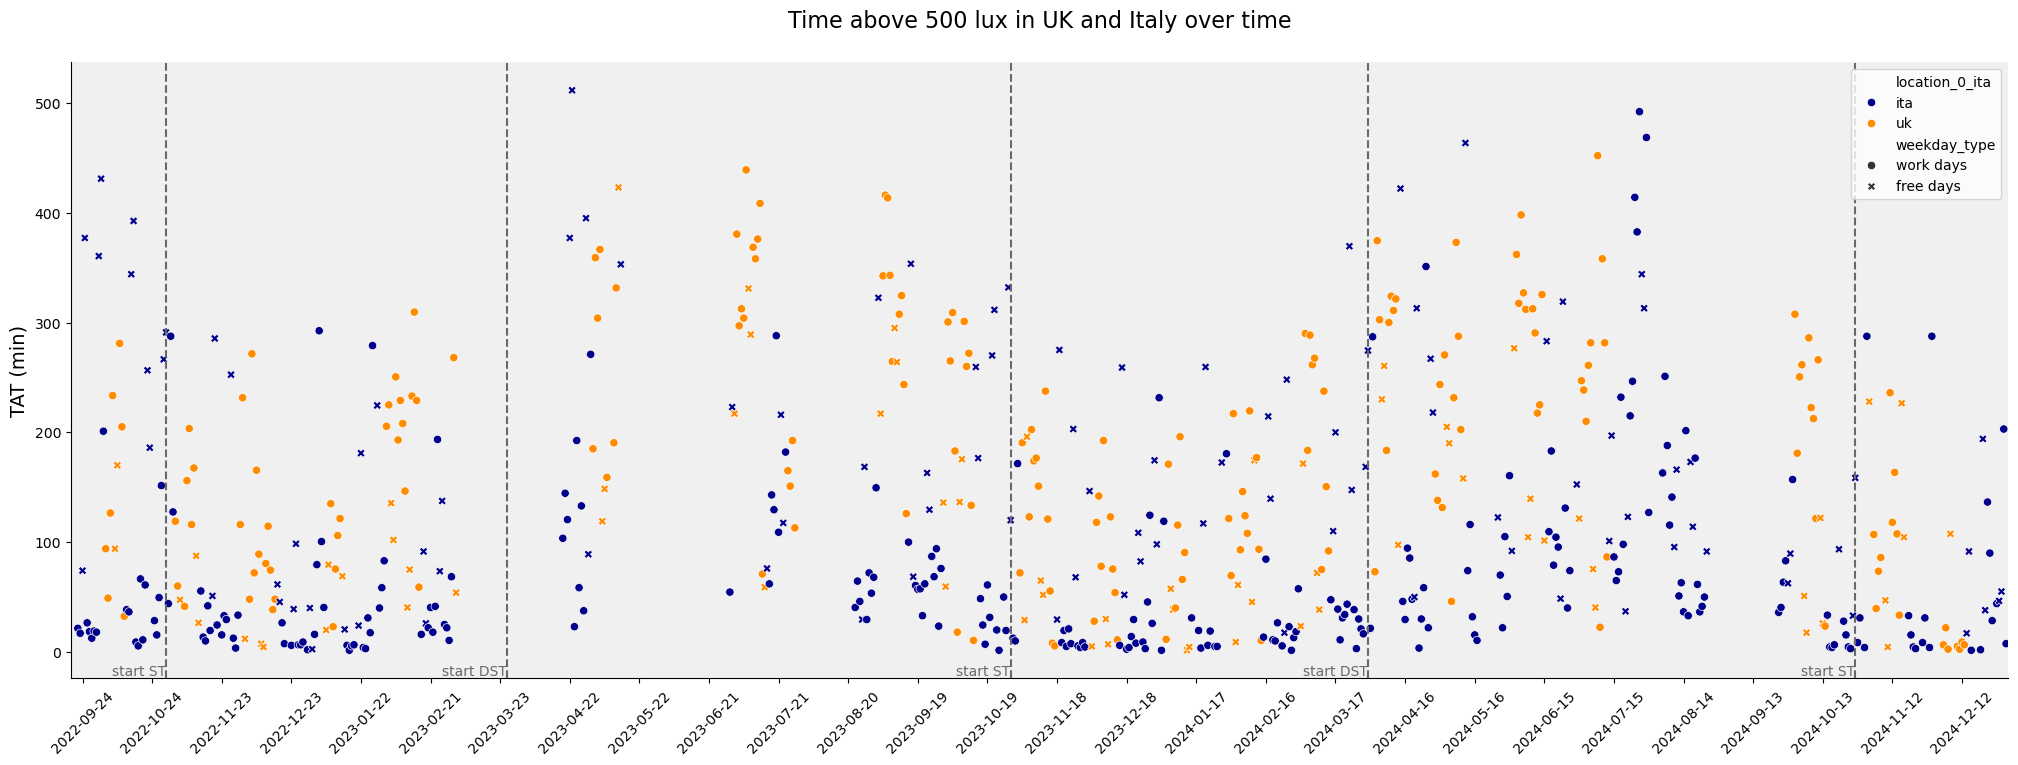

In [70]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='TATp500_min', hue='location_0_ita', style='weekday_type', data=df_TATp500, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('TAT (min)', fontsize=14)
ax1.set_title('Time above 500 lux in UK and Italy over time\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

_TATp1000_

In [71]:
df_TATp1000 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_1000')

In [72]:
df_TATp1000['location_0_ita'] = df_TATp1000['location_0_ita'].replace({0: 'ita', 1: 'uk'})

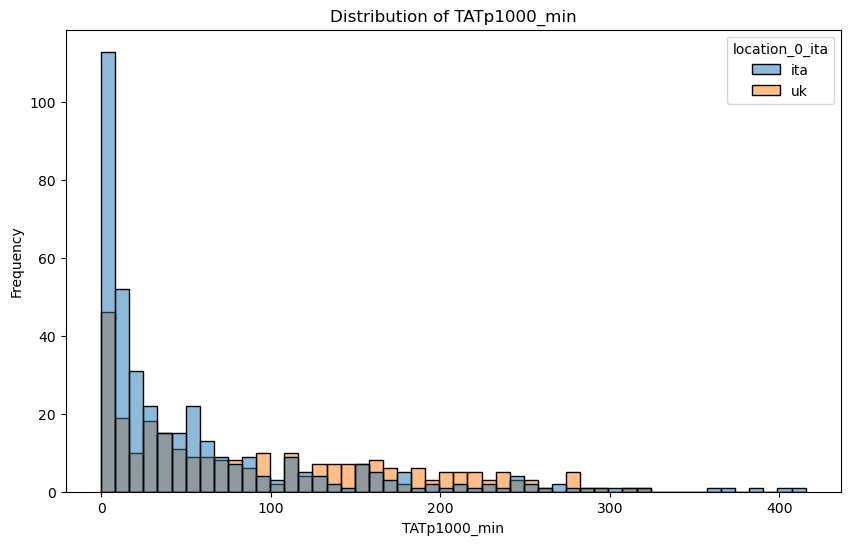

In [73]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp1000, x='TATp1000_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp1000_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp1000_min')
plt.show()

In [74]:
shapiro_test_tatp1000 = stats.shapiro(df_TATp1000['TATp1000_min'])

shapiro_test_tatp1000

ShapiroResult(statistic=0.8204288672417093, pvalue=1.4480111227687825e-26)

In [75]:
utest_location_tatp1000 = stats.mannwhitneyu(df_TATp1000[df_TATp1000['location_0_ita'] == 'ita']['TATp1000_min'], df_TATp1000[df_TATp1000['location_0_ita'] == 'uk']['TATp1000_min'])

utest_location_tatp1000

MannwhitneyuResult(statistic=38043.5, pvalue=2.289832338072761e-10)

In [76]:
# by location and mean,std,min and max of 'TATp1000_min
df_TATp1000_loc = df_TATp1000.groupby('location_0_ita').agg({'TATp1000_min': ['mean', 'std', 'min', 'max']})
df_TATp1000_loc

TATp1000_min                       
                       mean        std  min    max
location_0_ita                                    
ita               56.931347  78.143590  0.0  415.5
uk                91.667870  82.386548  0.0  320.5

In [77]:
# Fix: Replace zero values in TATp1000_min with a small positive value
df_TATp1000["TATp1000_min"] = df_TATp1000["TATp1000_min"].replace(0, 1e-6)

# Fit a GLM with Gamma distribution and correct log link function
glm_model_fixed = smf.glm(
    "TATp1000_min ~ location_0_ita + photoperiod + C(weekday_type)",
    data=df_TATp1000,
    family=sm.families.Gamma(link=sm.families.links.Log())  # Fix deprecated log alias
).fit()

# Display the corrected regression summary
glm_model_fixed.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           TATp1000_min   No. Observations:                  663
Model:                            GLM   Df Residuals:                      659
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          1.4352
Method:                          IRLS   Log-Likelihood:                -3172.7
Date:                Thu, 24 Apr 2025   Deviance:                       2918.5
Time:                        10:45:39   Pearson chi2:                     946.
No. Iterations:                    17   Pseudo R-squ. (CS):            0.04029
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        4.2875      0.224     19.153      0.000       3.849       4.726
location_0_ita[T.uk]             0.5300      0.100      5.306      0.000       0.334       0.726
C(weekday_type)[T.work days]     0.0176      0.104      0.170      0.865      -0.185       0.221
photoperiod                     -0.0245      0.019     -1.311      0.190      -0.061       0.012
================================================================================================
"""

In [78]:
#convert the coefficients to the original scale and print them
coef = np.exp(glm_model_fixed.params)
print(coef)

Intercept                       72.786662
location_0_ita[T.uk]             1.699000
C(weekday_type)[T.work days]     1.017712
photoperiod                      0.975793
dtype: float64


In [79]:
# convert the coef in percentage
coef = np.exp(glm_model_fixed.params) - 1
coef = coef * 100
print(coef)

Intercept                       7178.666194
location_0_ita[T.uk]              69.900017
C(weekday_type)[T.work days]       1.771221
photoperiod                       -2.420700
dtype: float64


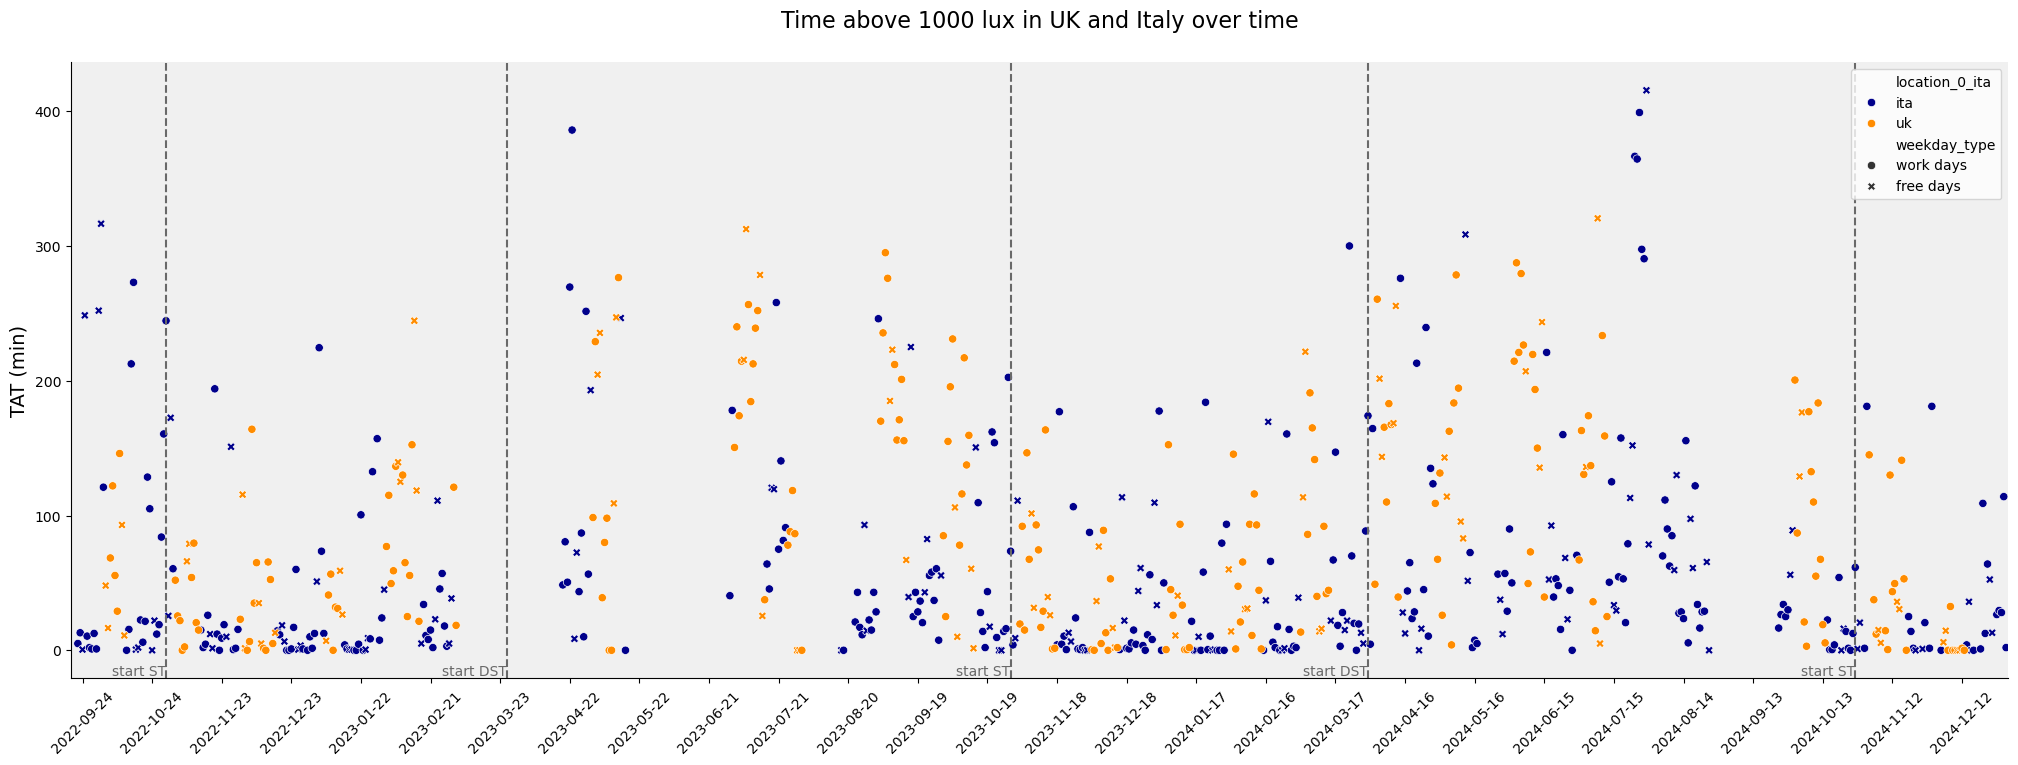

In [80]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='TATp1000_min', hue='location_0_ita', style='weekday_type', data=df_TATp1000, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('TAT (min)', fontsize=14)
ax1.set_title('Time above 1000 lux in UK and Italy over time\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

_TATp2500_

In [81]:
df_TATp2500 = pd.read_excel(fpath + '\\v3_lightdataset_avg.xlsx', sheet_name = 'TATp_2500')

In [82]:
df_TATp2500['location_0_ita'] = df_TATp2500['location_0_ita'].replace({0: 'ita', 1: 'uk'})

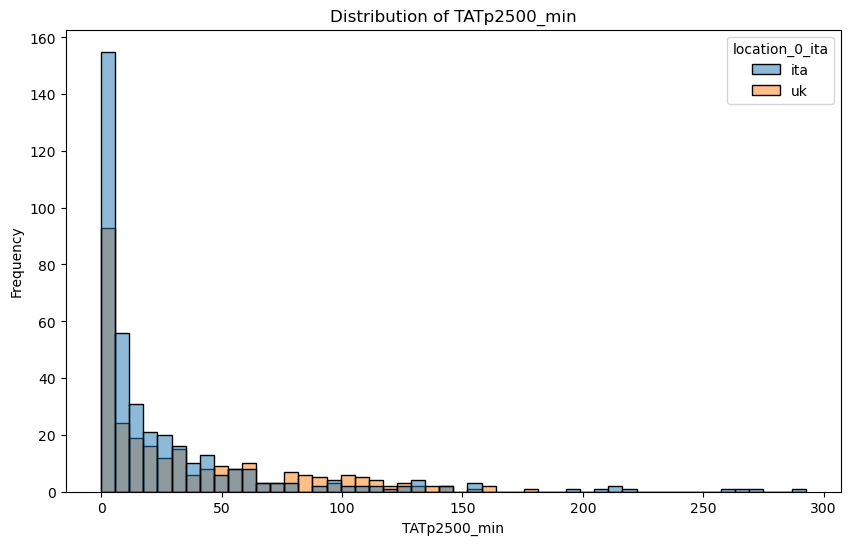

In [83]:
#distribution of mean 
plt.figure(figsize=(10,6))
sns.histplot(data=df_TATp2500, x='TATp2500_min', kde = False, bins = 50, hue='location_0_ita')
plt.xlabel('TATp2500_min')
plt.ylabel('Frequency')
plt.title('Distribution of TATp2500_min')
plt.show()

In [84]:
shapiro_test_tatp2500 = stats.shapiro(df_TATp2500['TATp2500_min'])

shapiro_test_tatp2500

ShapiroResult(statistic=0.708830045211001, pvalue=2.5013048887493885e-32)

In [85]:
utest_location_tatp2500 = stats.mannwhitneyu(df_TATp2500[df_TATp2500['location_0_ita'] == 'ita']['TATp2500_min'], df_TATp2500[df_TATp2500['location_0_ita'] == 'uk']['TATp2500_min'])

utest_location_tatp2500

MannwhitneyuResult(statistic=45698.5, pvalue=0.001342451508025129)

In [86]:
# by location and mean,std,min and max of 'TATp2500_min
df_TATp2500_loc = df_TATp2500.groupby('location_0_ita').agg({'TATp2500_min': ['mean', 'std', 'min', 'max']})
df_TATp2500_loc

TATp2500_min                       
                       mean        std  min    max
location_0_ita                                    
ita               26.940415  45.566766  0.0  292.5
uk                35.054152  40.855844  0.0  177.5

In [87]:
# Fix: Replace zero values in TATp2500_min with a small positive value
df_TATp2500["TATp2500_min"] = df_TATp2500["TATp2500_min"].replace(0, 1e-6)

# Fit a GLM with Gamma distribution and correct log link function
glm_model_fixed = smf.glm(
    "TATp2500_min ~ C(location_0_ita) + photoperiod + C(weekday_type)",
    data=df_TATp2500,
    family=sm.families.Gamma(link=sm.families.links.Log())  # Fix deprecated log alias
).fit()

# Display the corrected regression summary
glm_model_fixed.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           TATp2500_min   No. Observations:                  663
Model:                            GLM   Df Residuals:                      659
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          2.2049
Method:                          IRLS   Log-Likelihood:                -1756.3
Date:                Thu, 24 Apr 2025   Deviance:                       5409.1
Time:                        10:45:40   Pearson chi2:                 1.45e+03
No. Iterations:                    22   Pseudo R-squ. (CS):            0.01384
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                        3.8734      0.277     13.960      0.000       3.330       4.417
C(location_0_ita)[T.uk]          0.3991      0.124      3.223      0.001       0.156       0.642
C(weekday_type)[T.work days]     0.0090      0.128      0.070      0.944      -0.243       0.261
photoperiod                     -0.0564      0.023     -2.436      0.015      -0.102      -0.011
================================================================================================
"""

In [88]:
#convert the coefficients to the original scale and print them
coef = np.exp(glm_model_fixed.params)
print(coef)

Intercept                       48.103852
C(location_0_ita)[T.uk]          1.490508
C(weekday_type)[T.work days]     1.009056
photoperiod                      0.945138
dtype: float64


In [89]:
# convert the coef in percentage
coef = np.exp(glm_model_fixed.params) - 1
coef = coef * 100
print(coef)

Intercept                       4710.385214
C(location_0_ita)[T.uk]           49.050792
C(weekday_type)[T.work days]       0.905618
photoperiod                       -5.486196
dtype: float64


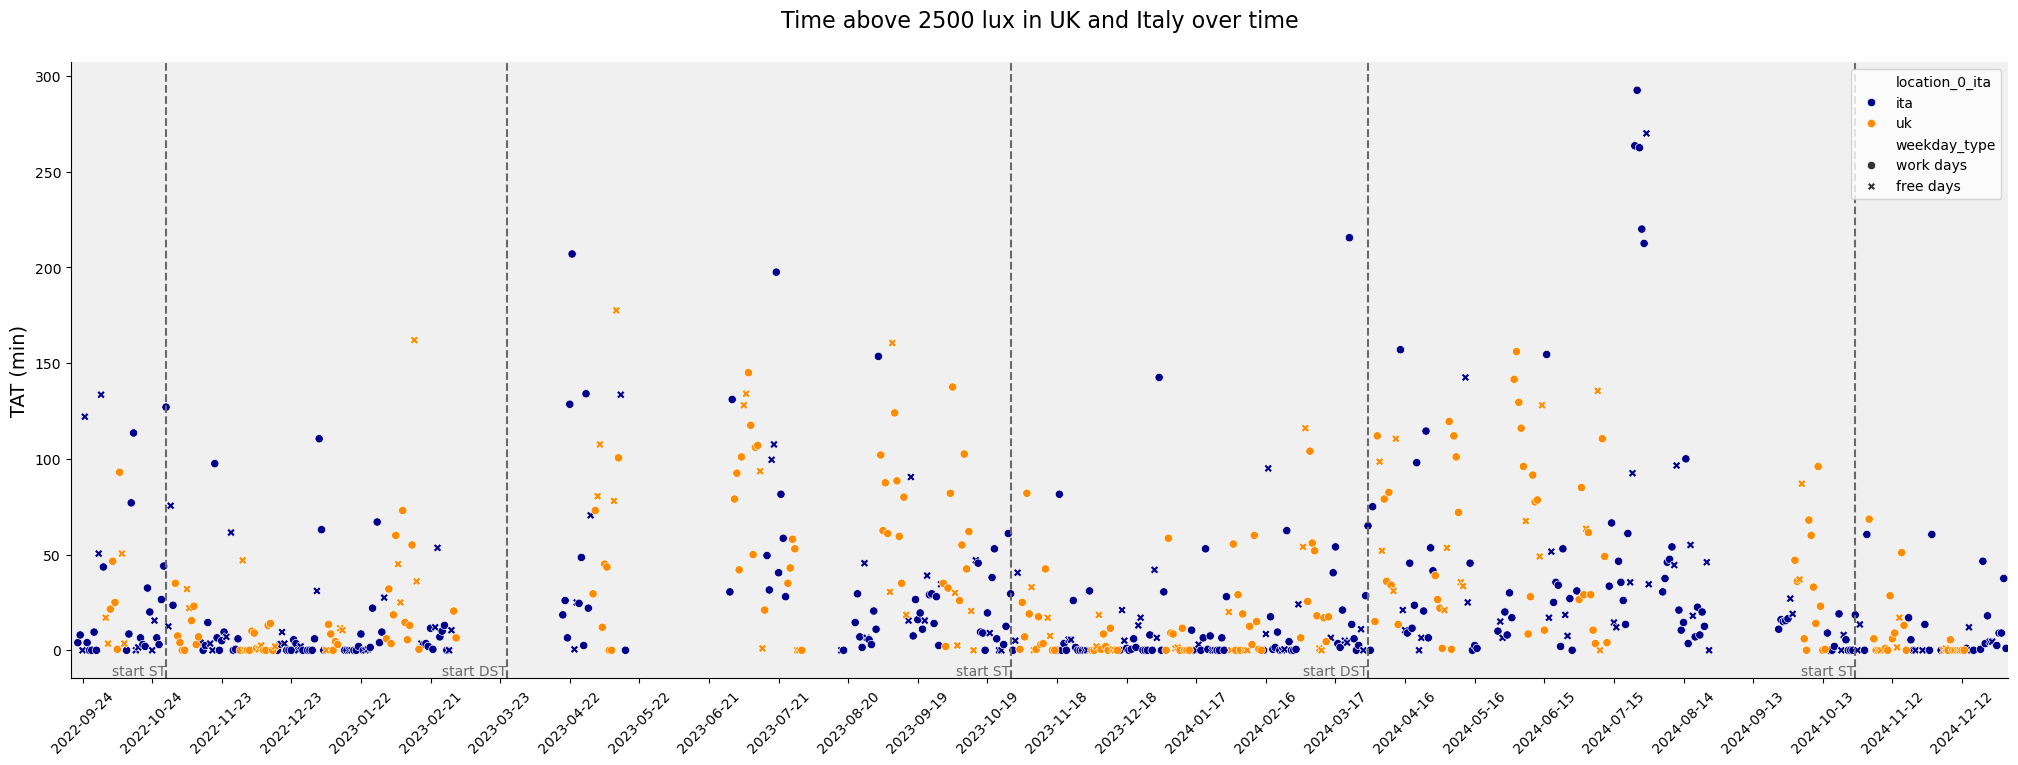

In [90]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# sleep onset and offset
sns.scatterplot(x='date', y='TATp2500_min', hue='location_0_ita', style='weekday_type', data=df_TATp2500, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('TAT (min)', fontsize=14)
ax1.set_title('Time above 2500 lux in UK and Italy over time\n', fontsize=16)

# Remove space y axis and plot
plt.gca().margins(x=0)

# Remove space y axis and plot
ax1.margins(x=0)

# add x axis ticks every 30 days and turn of 45 degrees
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=30))
plt.xticks(rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()